## Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Read excel file
df = pd.read_excel('integrated_data_with_sic.xlsx')
print(df.shape)

(16753, 37)


##  Preprocessing Part

#### Add variables 15_24, 15_64, covid

In [3]:

# Combine year + Quarter
df['quarter'] = df['quarter'].str.extract('(\d+)').astype(int)
df['year_quarter'] = df['year']*10 + df['quarter']

# Add productive population (15 ~ 24, 15 ~ 64) 경제 활동인구 
a15_64 = [24900.33333, 25418.66667, 25224.33333, 25249.33333, 25288, 25803.66667, 25731, 25494.66667, 25346.33333,
          25790.66667, 25632, 25552.66667, 25398.66667, 25702.33333, 25429.66667, 25359.66667]
a15_24 = [1480, 1582.666667, 1546, 1466.666667, 1560.666667, 1607.333333, 1564, 1439.333333, 1475.666667, 1470.666667, 1456.333333,
          1389.666667, 1387, 1405.666667, 1341.333333, 1259.666667]
a15_64 = list(map(int, a15_64))
a15_24 = list(map(int, a15_24))

df['a15_64'] = df.apply(lambda row: a15_64[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)
df['a15_24'] = df.apply(lambda row: a15_24[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)

# Add Covid-19 data

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
covid_data = pd.read_csv(url)
covid_data["date"] = pd.to_datetime(covid_data["date"])

korea = covid_data[covid_data["location"] == "South Korea"].copy()
korea = korea[(korea["date"] >= "2021-01-01") & (korea["date"] <= "2024-12-31")]
korea_indexed = korea.set_index('date')
korea_quarterly = korea_indexed.resample('QE').mean(numeric_only=True)

#  'reproduction_rate' 도 고려해볼만 함 (감영 재생산 지수)
korea_quarterly = korea_quarterly['new_cases_per_million'].astype(int).to_numpy()
korea_quarterly = np.append(korea_quarterly, 0)
print(korea_quarterly)

df['covid'] = df.apply(lambda row: korea_quarterly[int((row['year']-2021) * 4 + row['quarter'] - 1)], axis=1)

[   9   11   31   64 2444 1342 1320  847  452  265  535    0    0    0
    0    0]


 # Handling Missing Variable

#### remove TimeSeries nan companies

In [4]:
# Handling Missing Values 
print(df.shape)

# 시계열이 누락된 기업 제거
all_quarters = sorted(df['year_quarter'].unique())
missing_dict = {}

for company, group in df.groupby('company_name'):
    existing = set(group['year_quarter'])
    missing = set(all_quarters) - existing
    
    if missing:  # 하나라도 빠졌다면
        missing_dict[company] = sorted(missing)

remove_list = list(missing_dict.keys())
# df_clean = df[~df['company_name'].isin(remove_list)]
# *** 위의 코드를 사용할지 말지는 데이터 추가 수집 후 고려해야 할 듯 ***
df_clean = df
print(df_clean.shape)
print(remove_list)

(16753, 40)
(16753, 40)
['DB손해보험', 'DB증권', 'DH오토웨어', 'DL', 'DS단석', 'HL D&I', 'HLB이노베이션', 'INVENI', 'KB손해보험', 'LG생활건강', 'LG화학', 'NH투자증권', 'SBI인베스트먼트', 'SKC', 'SK증권', '교보증권', '국민은행', '금빛', '기업은행', '넥슨지티', '녹십자', '녹십자셀', '녹십자홀딩스', '다올투자증권', '대선조선', '대성창투', '대신증권', '동원산업', '드림라인', '럭슬', '롯데손해보험', '롯데푸드', '리드코프', '메리츠증권', '메리츠화재해상보험', '메이슨캐피탈', '무림SP', '미래에셋증권', '부국증권', '부산도시가스', '부산은행', '비츠로시스', '비케이탑스', '산은캐피탈', '삼미금속', '삼성생명', '삼성전기', '삼성증권', '삼성카드', '삼성화재해상보험', '상상인증권', '성원', '성지건설', '소리바다', '스튜디오에스', '스틱인베스트먼트', '스포츠서울', '시지메드텍', '신세계톰보이', '신영증권', '신한은행', '신한지주', '신한카드', '신한투자증권', '아리온테크놀로지', '아이에스동서', '아이엠뱅크', '아주IB투자', '아진카인텍', '에스에이치엔엘', '에스유앤피', '에스지신성건설', '에스케이머티리얼즈', '에스케이브로드밴드', '에스케이엔펄스', '에이치디씨영창', '에이치엔에스하이텍', '엘에스일렉트릭', '엠로', '엠소닉', '우리금융캐피탈', '우리기술투자', '우리은행', '우리종합금융', '우전', '원풍물산', '웹케시', '유성티엔에스', '유안타증권', '유진증권', '유화증권', '이마트에브리데이', '전북은행', '제네시스디벨롭먼트홀딩스', '제이웨이', '제주은행', '조광피혁', '주성엔지니어링', '지에스홈쇼핑', '체시스', '케이맥', '케이비증권', '케이비캐피탈', '코너스톤네트웍스', '코리안리', '코오롱글로벌', '코원플레이'

#### Handeling Computable Missing values (오차 없이 확정적으로 채울 수 있는 경우)

In [5]:
# Handling missing total_liabilities
total_liabilities_mask = df_clean['total_liabilities'].isnull() & df_clean['total_assets'].notnull() & df_clean['total_equity'].notnull()
df_clean.loc[total_liabilities_mask, 'total_liabilities'] = df_clean.loc[total_liabilities_mask, 'total_assets'] - df_clean.loc[total_liabilities_mask, 'total_equity']

# Handling missing total_equity
total_equity_mask = df_clean['total_equity'].isnull() & df_clean['total_assets'].notnull() & df_clean['total_liabilities'].notnull()
df_clean.loc[total_equity_mask, 'total_equity'] = df_clean.loc[total_equity_mask, 'total_assets'] - df_clean.loc[total_equity_mask, 'total_liabilities']

# Handling missing dept_ratio
dept_ratio_mask = df_clean['debt_ratio'].isnull() & df_clean['total_equity'].notnull() & df_clean['total_liabilities'].notnull()
df_clean.loc[dept_ratio_mask, 'debt_ratio'] = (df_clean.loc[dept_ratio_mask, 'total_liabilities'] / df_clean.loc[dept_ratio_mask, 'total_equity'])


# Check
print(df_clean['total_liabilities'].isnull().sum())
print(df_clean['total_equity'].isnull().sum())
print(df_clean['debt_ratio'].isnull().sum())

0
0
0


In [6]:
# 대분류, 중분류, 소분류 missing 
df_clean.loc[df_clean['industry_code'] == 26,'industry_code'] = 265
df_clean['industry_code'] = df_clean['industry_code'].astype(str).apply(lambda x: x.zfill(5)[:3] if len(x) >= 4 else x.zfill(3))

# 코드북 누락 채우기
industry_CodeBook_raw = pd.read_excel('한국표준산업분류(10차)_표.xlsx', header=1)
industry_CodeBook_df = industry_CodeBook_raw.iloc[:, :6].copy().ffill()
industry_CodeBook_df['Unnamed: 1'] = industry_CodeBook_df['Unnamed: 1'].str.replace(r'\(.*\)', '', regex=True)

# 소분류 코드 3자리로 만든 후 딕셔너리 생성
code_key = industry_CodeBook_df['소분류(232)'].astype(str).str.zfill(3)

dict_large = dict(zip(code_key, industry_CodeBook_df['Unnamed: 1']))
dict_middle = dict(zip(code_key, industry_CodeBook_df['Unnamed: 3']))
dict_small = dict(zip(code_key, industry_CodeBook_df['Unnamed: 5']))

df_clean['대분류'] = df_clean['대분류'].fillna(df_clean['industry_code'].map(dict_large))
df_clean['중분류'] = df_clean['중분류'].fillna(df_clean['industry_code'].map(dict_middle))
df_clean['소분류'] = df_clean['소분류'].fillna(df_clean['industry_code'].map(dict_small))

# Anomaly Detection 

In [7]:
# Classifying Variable Types

num_features = ['year_quarter', 'year', 'quarter','establishment_date', 'total_assets',
       'total_liabilities', 'total_equity', 'operating_income', 'net_income',
       'company_age', 'company_size', 'debt_ratio', 'operating_profit_margin',
       'exchange_rate', 'cpi', 'interest_rate', 'unemployment_rate',
       'employment_rate', 'industrial_production_index', 'employed',
       'unemployed', 'heat_wave_days', 'cold_wave_days', 'heavy_rain_days',
       'avg_temperature', 'total_precipitation', 'a15_64', 'a15_24', 'covid']

str_features = ['business_registration_no', 'stock_code', 'company_name', 'industry_code', 'statement_type', 'address',
       'corp_type', 'station_name', '대분류', '중분류', '소분류']

key_observation_items = ['total_assets', 'total_liabilities', 'total_equity', 'operating_income', 'net_income']

In [8]:
def Anomaly_Detection(features, min_threshold, max_threshold):
    anomaly = {}
    for x in features:
            extreme_mask = (df_clean[x] < min_threshold) | (df_clean[x] > max_threshold)
            if extreme_mask.sum() > 0:
                    anomaly[x] = [extreme_mask.sum(), df_clean['company_name'][extreme_mask].unique()]
                    
    print()
    print('-' * 100)
    anomaly_company = []
    for feat in anomaly.keys():
            print('**{}** : has outlires in {} company \n'.format(feat, list(anomaly[feat][1])))
            anomaly_company += list(anomaly[feat][1])
    print('-' * 100)
    return list(set(anomaly_company))
    

# 1000조 이상의 진짜 말도 안되는 것들 
# print(Anomaly_Detection(key_observation_items, -1e15, 1e15))
# print(Anomaly_Detection(num_features, -1e15, 1e15))

In [9]:
# Key_features Anomaly Detection with precise values
a = Anomaly_Detection(['total_assets'],0, 1e15) # 1000조
b = Anomaly_Detection(['total_liabilities'],0, 1e15)
c = Anomaly_Detection(['total_equity'],-1e14, 1e15)
d = Anomaly_Detection(['operating_income'],-1e14, 1e14)
e = Anomaly_Detection(['net_income'],-1e14, 1e14)
f = Anomaly_Detection(['debt_ratio'],-1e9, 1e9)

# stock_code of Anomaly companies
total_anomaly_list = list(set(a + b + c + d + e + f))
print(total_anomaly_list)
print(len(total_anomaly_list))


----------------------------------------------------------------------------------------------------
**total_assets** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**total_liabilities** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**total_equity** : has outlires in ['소노스퀘어', '소프트센', '제이앤케이인더스트리'] company 

----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
**operating_income** : has outlires in ['소노스퀘어', '소프트

# repair nan or anomaly_companies

In [10]:
# Check nan cols
df_clean['net_income'] = df_clean['net_income'].replace(0.0, np.nan)
nan_df = df_clean[['operating_income', 'net_income', 'operating_profit_margin']]
print(nan_df.isnull().sum())

# masking nan or anomaly df
nan_mask = ((df_clean['operating_income'].isna()) |
            (df_clean['net_income'].isna()) | 
            (df_clean['operating_profit_margin'].isna()) | 
            (df_clean['company_name'].isin(total_anomaly_list)) | # 이상치 기업 수집 
            (df_clean['company_name'].isin(remove_list))) # 시계열 누락 기업도 추가로 수집 

# final sets for Dart API
repair_df = df_clean.loc[nan_mask, ['company_name', 'stock_code']]
print('\n원본 shape :',repair_df.shape)
print('유니크 기업 수 : ',repair_df['company_name'].unique().shape)
repair_df = repair_df.drop_duplicates(subset=['stock_code'])[['company_name', 'stock_code']].reset_index(drop=True)
print('최종 API 요청용 shape : ', repair_df.shape)

operating_income            483
net_income                 5522
operating_profit_margin     483
dtype: int64

원본 shape : (6494, 2)
유니크 기업 수 :  (849,)
최종 API 요청용 shape :  (849, 2)


In [11]:
import OpenDartReader
import time


# 1. DART API Settings

my_api_key = '7b786b66f473a1d6d2a9d103b4e99b941dfd0062'
dart = OpenDartReader(my_api_key)

# 1. Import corp_codes from DART server
dart_master = dart.corp_codes

# 2. Set stock_code len = 6
repair_df['stock_code'] = repair_df['stock_code'].astype(str).str.zfill(6)

# 3. Merge Left corp_code by stock_code on repair_df
repair_df = pd.merge(repair_df, dart_master[['corp_code', 'stock_code']], on='stock_code', how='left')

# 4. Remove company not in DART
print(f"🔍 매칭 전 기업 수: {len(repair_df)}개")
repair_df = repair_df.dropna(subset=['corp_code']).reset_index(drop=True)
print(f"✅ 매칭 후(corp_code 확보) 최종 API 대기 기업 수: {len(repair_df)}개")

# 5. Check
print(repair_df.head())

🔍 매칭 전 기업 수: 849개
✅ 매칭 후(corp_code 확보) 최종 API 대기 기업 수: 849개
  company_name stock_code corp_code
0         신한은행     000010  00149293
1         동화약품     000020  00119195
2         우리은행     000030  00254045
3        KR모터스     000040  00112378
4           경방     000050  00101628


In [12]:
print(repair_df['corp_code'].dtypes)
print(repair_df['stock_code'].dtypes)

str
str


In [14]:
import time
import pandas as pd
import os
from contextlib import redirect_stdout

target_years = ['2021', '2022', '2023', '2024']
quarter_dict = {
    '11013': '1Q',       
    '11012': '2Q', 
    '11014': '3Q',       
    '11011': '4Q'  
    }

print('📊 오늘 수집 목표 연도 : {}'.format(target_years))
print('데이터 수집을 시작합니다 ... \n')

error_log = []

# main loop for collecting data from Dart (Year)
for year in target_years:
    print(f"================ [ {year}년도 수집 시작 ] ================")
    yearly_data_list = []

    # Circuit by (Company)
    for index, row in repair_df.iterrows():
        c_code = row['corp_code']
        s_code = row['stock_code']
        c_name = row['company_name']

        # Circuit by (Quarter)
        for r_code, q_label in quarter_dict.items():
            try:
                # Call DART API
                with open(os.devnull, 'w') as devnull:
                    with redirect_stdout(devnull):
                        fs_df = dart.finstate(c_code, year, r_code)

                if fs_df is not None and not fs_df.empty:
                    fs_df['stock_code'] = s_code
                    fs_df['company_name'] = c_name
                    fs_df['year'] = year
                    fs_df['quarter'] = q_label
                    yearly_data_list.append(fs_df)
                else:
                    # 통신은 성공했으나 데이터가 없는 경우 (미공시)
                    error_log.append({'company_name': c_name, 'stock_code': s_code, 'year': year, 'quarter': q_label, 'error': '데이터 없음(미공시)'})

            except Exception as e:
                # 통신 에러 등 예외 발생 시
                error_log.append({'company_name': c_name, 'stock_code': s_code, 'year': year, 'quarter': q_label, 'error': str(e)})
            
            time.sleep(0.3)

        if (index + 1) % 100 == 0:
            print("🔄 진행 중 ... {} / {} 개 기업 완료".format(index + 1, len(repair_df)))
    
    # 연도가 끝날 때마다 데이터 백업
    if yearly_data_list:
        yearly_df = pd.concat(yearly_data_list, ignore_index=True)
        file_name = f'dart_repaired_data_{year}.csv'
        yearly_df.to_csv(file_name, index=False, encoding='utf-8-sig')
        print(f"💾 {year}년도 복구 데이터 저장 완료: {file_name}")
    else:
        print(f"⚠️ {year}년도에 수집된 정상 데이터가 없습니다.")

print("\n✅ 모든 데이터 수집 완료!")

# ---------------------------------------------------------
# 💡 추가된 핵심 로직: 수집 종료 후 에러 로그를 CSV로 저장
# ---------------------------------------------------------
if error_log:
    error_df = pd.DataFrame(error_log)
    error_file_name = 'dart_missing_error_log.csv'
    error_df.to_csv(error_file_name, index=False, encoding='utf-8-sig')
    print(f"🚨 총 {len(error_df)}건의 누락/에러가 감지되어 '{error_file_name}'에 저장되었습니다.")
else:
    print("🎉 완벽합니다! 단 한 건의 에러나 누락도 발생하지 않았습니다.")

📊 오늘 수집 목표 연도 : ['2021', '2022', '2023', '2024']
데이터 수집을 시작합니다 ... 

================ [ 2021년도 수집 시작 ] ================
🔄 진행 중 ... 100 / 849 개 기업 완료
🔄 진행 중 ... 200 / 849 개 기업 완료
🔄 진행 중 ... 300 / 849 개 기업 완료
🔄 진행 중 ... 400 / 849 개 기업 완료
🔄 진행 중 ... 500 / 849 개 기업 완료
🔄 진행 중 ... 600 / 849 개 기업 완료
🔄 진행 중 ... 700 / 849 개 기업 완료
🔄 진행 중 ... 800 / 849 개 기업 완료
💾 2021년도 복구 데이터 저장 완료: dart_repaired_data_2021.csv
================ [ 2022년도 수집 시작 ] ================
🔄 진행 중 ... 100 / 849 개 기업 완료
🔄 진행 중 ... 200 / 849 개 기업 완료
🔄 진행 중 ... 300 / 849 개 기업 완료
🔄 진행 중 ... 400 / 849 개 기업 완료
🔄 진행 중 ... 500 / 849 개 기업 완료
🔄 진행 중 ... 600 / 849 개 기업 완료
🔄 진행 중 ... 700 / 849 개 기업 완료
🔄 진행 중 ... 800 / 849 개 기업 완료
💾 2022년도 복구 데이터 저장 완료: dart_repaired_data_2022.csv
================ [ 2023년도 수집 시작 ] ================
🔄 진행 중 ... 100 / 849 개 기업 완료
🔄 진행 중 ... 200 / 849 개 기업 완료
🔄 진행 중 ... 300 / 849 개 기업 완료
🔄 진행 중 ... 400 / 849 개 기업 완료
🔄 진행 중 ... 500 / 849 개 기업 완료
🔄 진행 중 ... 600 / 849 개 기업 완료
🔄 진행 중 ... 700 / 849 개 기업 완료
🔄 진행 중 ..

#### split train_set, test_set by companies

In [ ]:
threshold = 0.8
companies = df_clean['company_name'].unique().tolist()
train_companies, test_companies = train_test_split(companies, train_size=threshold, random_state=42)

train_set = df_clean[df_clean['company_name'].isin(train_companies)]
test_set = df_clean[df_clean['company_name'].isin(test_companies)]

print(train_set.shape, test_set.shape)

(12512, 40) (3136, 40)


# Check variable distribution

In [ ]:
print(len(num_features), len(str_features))

29 11


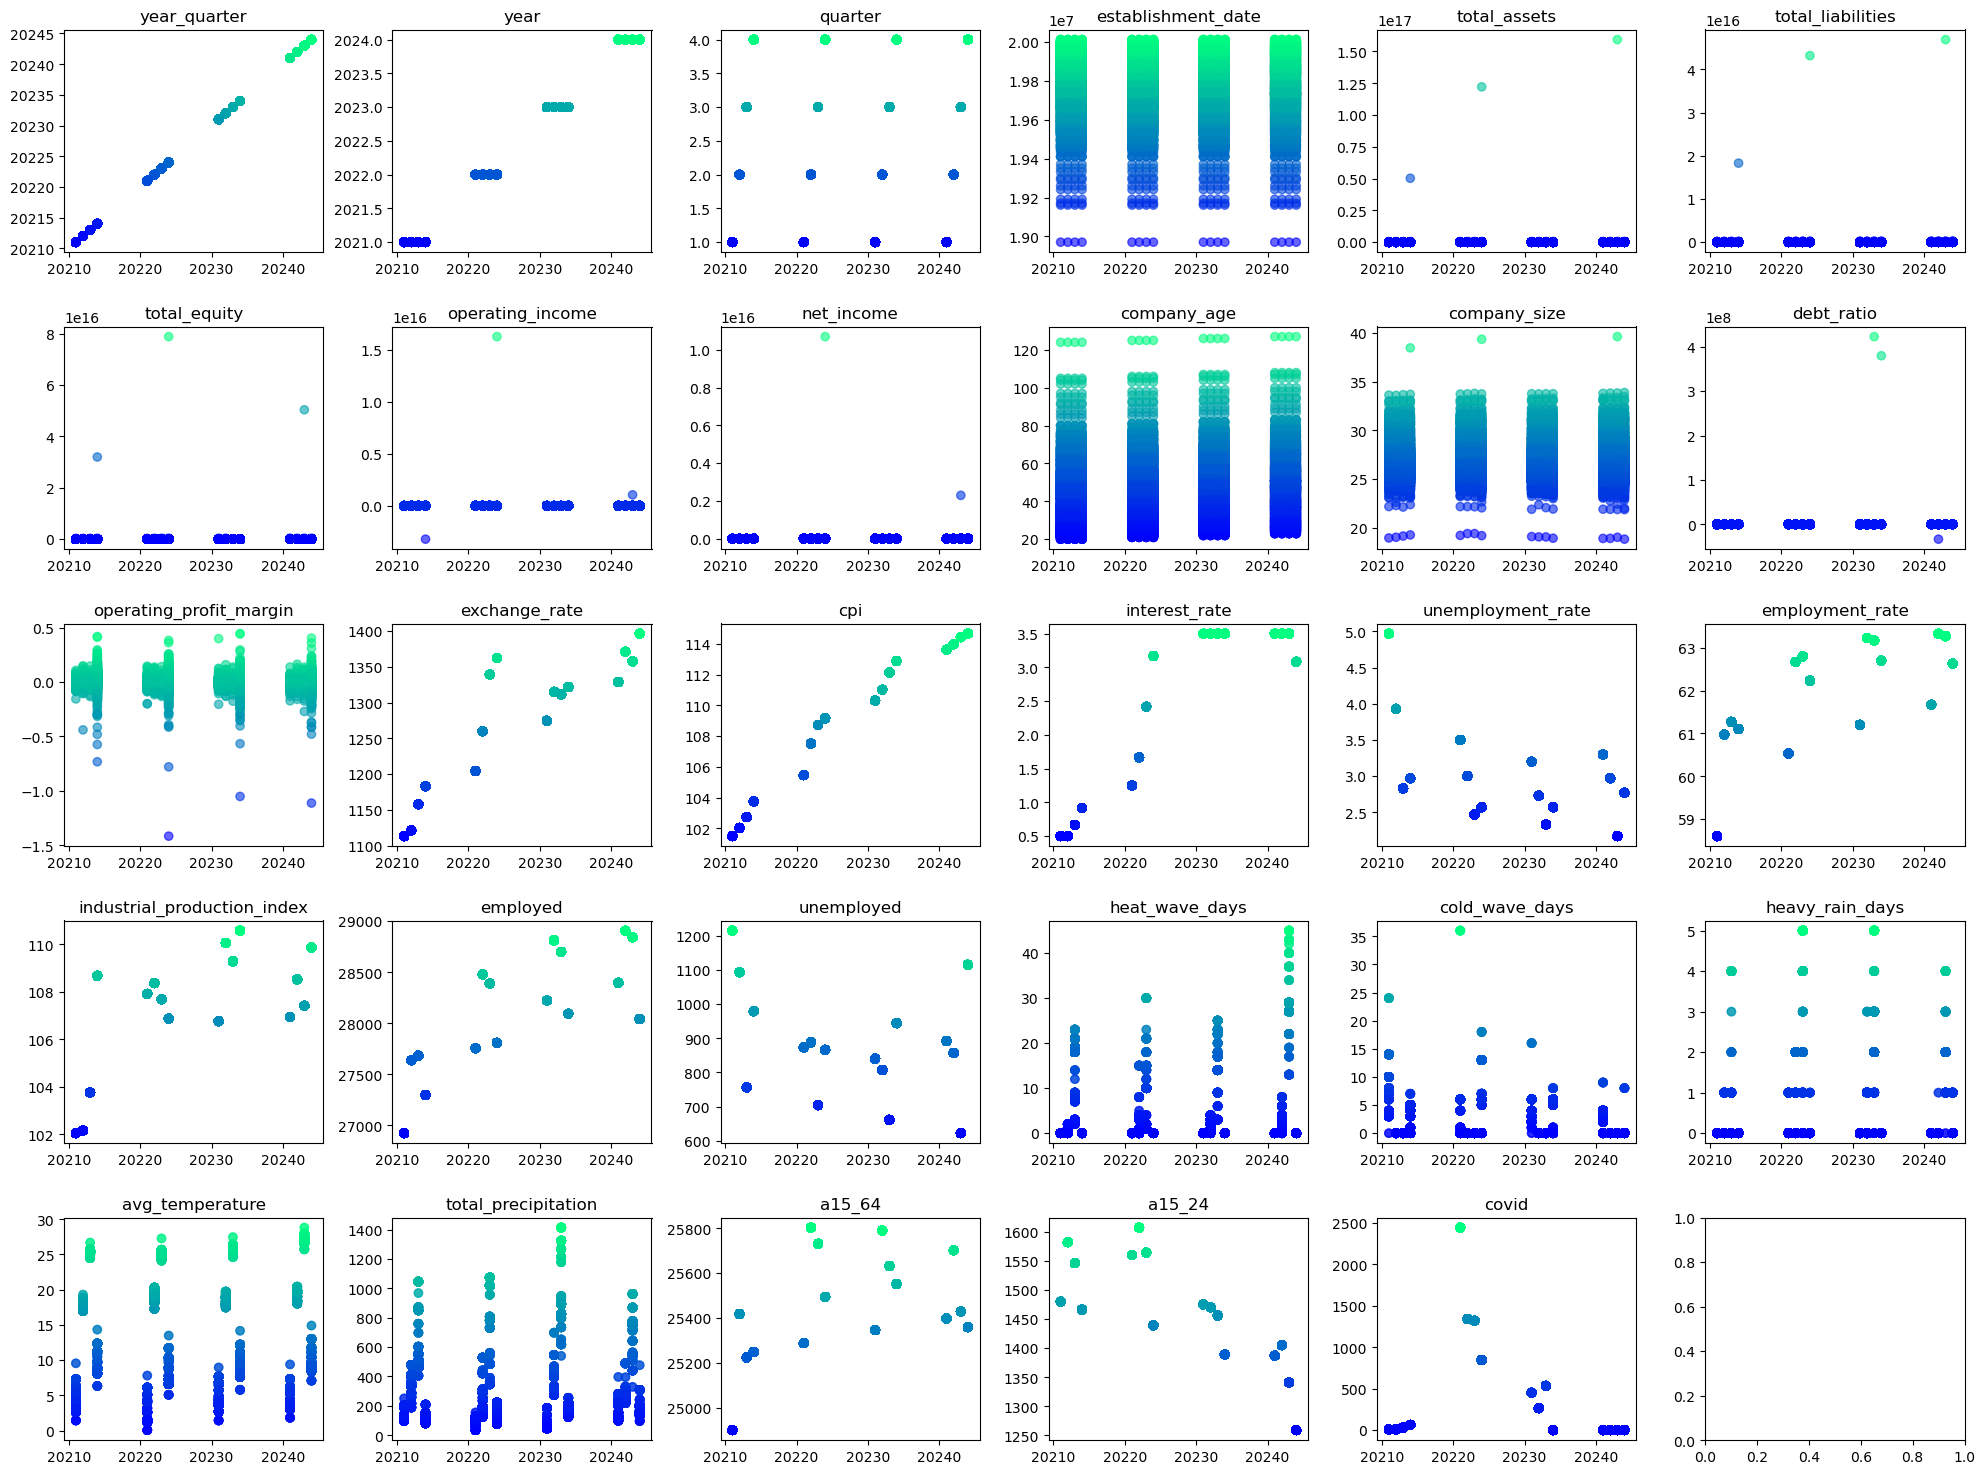

In [ ]:
df_clean = df_clean.sort_values(by=['company_name', 'year_quarter'])

# num_features graph
fig, ax = plt.subplots(5, 6)

# grid size settings
fig.set_size_inches((20, 15))

# grig blank settings
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for row in range(5):
    for col in range(6):
        
        if row * 6 + col > len(num_features)-1 : break

        ax[row, col].scatter(df_clean['year_quarter'] ,df_clean[num_features[row * 6 + col]], c=df_clean[num_features[row * 6 + col]],cmap='winter', alpha=0.6)
        ax[row, col].set_title(num_features[row * 6 + col])
        
plt.tight_layout()
plt.show()

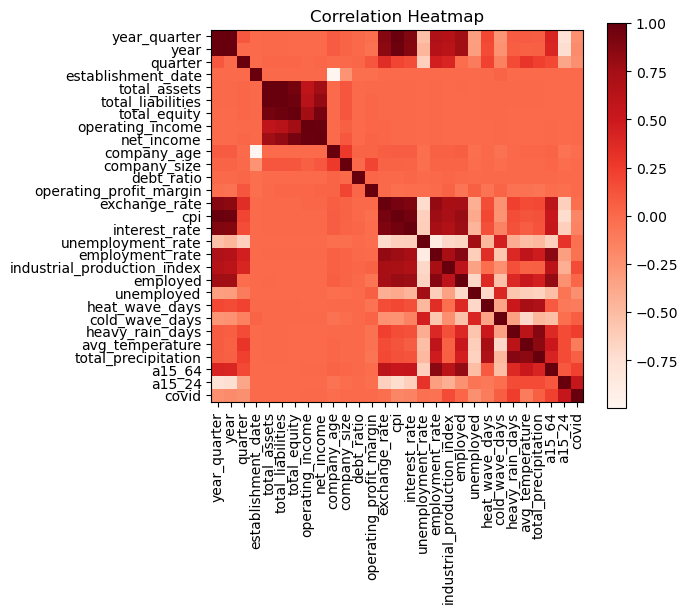

In [ ]:
corr = df_clean[num_features].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr[num_features], cmap='Reds')

plt.colorbar()
plt.xticks(range(len(num_features)), num_features, rotation=90)
plt.yticks(range(len(num_features)), num_features)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# threshold 설정
threshold = 0.8

# 상관행렬 절댓값
corr_matrix = corr.abs()

# 상삼각 행렬만 사용 (중복 제거)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# threshold 이상인 feature 쌍 찾기
high_corr_pairs = [
    (column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, column]) and upper.loc[row, column] > threshold
]
# 결과 출력
for f1, f2, value in high_corr_pairs:
    print(f"{f1}  <->  {f2} : {value:.3f}")

year  <->  year_quarter : 0.995
total_liabilities  <->  total_assets : 0.996
total_equity  <->  total_assets : 0.941
total_equity  <->  total_liabilities : 0.969
net_income  <->  total_liabilities : 0.817
net_income  <->  total_equity : 0.937
net_income  <->  operating_income : 0.989
company_age  <->  establishment_date : 0.997
exchange_rate  <->  year_quarter : 0.873
exchange_rate  <->  year : 0.842
cpi  <->  year_quarter : 0.980
cpi  <->  year : 0.965
cpi  <->  exchange_rate : 0.933
interest_rate  <->  year_quarter : 0.893
interest_rate  <->  year : 0.882
interest_rate  <->  exchange_rate : 0.902
interest_rate  <->  cpi : 0.946
employment_rate  <->  exchange_rate : 0.814
employment_rate  <->  unemployment_rate : 0.875
employed  <->  employment_rate : 0.873
total_precipitation  <->  heavy_rain_days : 0.873
total_precipitation  <->  avg_temperature : 0.841
a15_64  <->  employment_rate : 0.859
a15_64  <->  employed : 0.808
